# Notebook de Entrenamiento Sistema predictivo para cancelacion de reservas

Este notebook está diseñado para desarrollar y entrenar un modelo de machine learning que permita predecir el cancelamiento de reservas en Maguestic. La capacidad de anticipar qué reservas tienen mayor probabilidad de ser canceladas es crucial para optimizar la gestión de recursos, mejorar la planificación operativa y aumentar la eficiencia del negocio.

El objetivo principal es analizar los datos históricos de reservas, identificar patrones relevantes y entrenar un modelo predictivo que ayude a tomar decisiones informadas y reducir el impacto negativo de los cancelamientos. Para ello, se utilizarán técnicas de limpieza y procesamiento de datos, selección de características, y diferentes algoritmos de machine learning, evaluando su desempeño para seleccionar la mejor opción.

## Resumen del Notebook

Este notebook se enfoca en la creación de un sistema predictivo para la cancelación de reservas hoteleras. A continuación, se detallan los pasos principales:

1.  **Importación de Librerías**: Se importan las herramientas necesarias para la manipulación de datos, modelado y visualización.
2.  **Carga de Datos**: Se descarga el dataset de Kaggle (`Hotel Reservations.csv`) y se carga en un DataFrame de pandas.
3.  **Preparación de Datos**: Se seleccionan y renombran columnas relevantes, se transforman variables (ej. `booking_status` a `isCanceled`), y se manejan posibles valores nulos.
4.  **División de Datos**: El conjunto de datos se divide en conjuntos de entrenamiento y prueba para evaluar el rendimiento del modelo.
5.  **Entrenamiento de Modelos Base**: Se entrenan y evalúan varios modelos de clasificación (RandomForest, GradientBoosting, HistGradientBoosting, XGBoost) utilizando métricas como Recall, Precision, F1-Score, AUC y Accuracy.
6.  **Optimización de Hiperparámetros**: El modelo con mejor rendimiento inicial (RandomForest) se optimiza utilizando `RandomizedSearchCV` para encontrar los mejores hiperparámetros.
7.  **Evaluación con Threshold Ajustado**: Se realiza un análisis de la curva Precision-Recall para seleccionar un umbral de clasificación óptimo, priorizando un `recall` alto con una `precision` mínima deseada.
8.  **Análisis de Importancia de Características**: Se visualiza la importancia de las características para entender qué variables influyen más en la predicción.
9.  **Persistencia del Modelo**: Se guarda el modelo optimizado y el umbral seleccionado para su uso futuro.
10. **Visualizaciones de Evaluación**: Se generan curvas ROC y Precision-Recall, además de una matriz de confusión para una evaluación exhaustiva del modelo.
11. **Función de Predicción**: Se crea una función `predict_cancellation` que toma nuevos datos y predice la probabilidad de cancelación, la predicción binaria y un nivel de riesgo (Bajo, Medio, Alto) utilizando el modelo y umbral entrenados.

## 1. Importacion de librerias

### Descripción de Librerías Importadas

En esta sección, se importan las librerías esenciales para todo el proceso de creación del sistema predictivo. Cada una cumple un rol específico:

*   **`pandas`**: Fundamental para la manipulación y análisis de datos, permitiendo trabajar con DataFrames de manera eficiente.
*   **`numpy`**: Proporciona soporte para arreglos y matrices, así como una colección de funciones matemáticas de alto nivel para operar con ellos.
*   **`matplotlib.pyplot`**: Una librería de visualización que se utilizará para crear gráficos estáticos, interactivos y animados, esenciales para el EDA y la evaluación del modelo.
*   **`sklearn.model_selection`**:
    *   `train_test_split`: Para dividir el conjunto de datos en subconjuntos de entrenamiento y prueba, asegurando que el modelo se evalúe con datos no vistos.
*   **`sklearn.metrics`**:
    *   Un conjunto de funciones para evaluar el rendimiento de los modelos de clasificación, incluyendo `recall_score`, `precision_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`, `roc_curve` y `precision_recall_curve`. Estas métricas son cruciales para entender cómo de bien predice el modelo, especialmente en problemas con clases desbalanceadas.
*   **`sklearn.tree.DecisionTreeClassifier`**: Aunque no se usa directamente como el modelo final, es el bloque de construcción de los modelos de ensemble basados en árboles.
*   **`sklearn.ensemble`**:
    *   `RandomForestClassifier`, `GradientBoostingClassifier`, `HistGradientBoostingClassifier`: Son modelos de ensemble robustos y de alto rendimiento que se utilizarán para la clasificación. Estos modelos son conocidos por su capacidad para manejar datos complejos y desbalanceados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

## 2. Carga de Datos

### Nota sobre el EDA (Análisis Exploratorio de Datos)

Dado que este dataset (`Hotel Reservations.csv`) proviene de Kaggle y ha sido extensamente estudiado y documentado por la comunidad, para este ejercicio nos enfocaremos directamente en la preparación y modelado. Omitiremos un EDA exhaustivo y partiremos de la premisa de que las variables seleccionadas y su transformación son las más relevantes para predecir la cancelación de reservas, especialmente aquellas que se correlacionan directamente con la información disponible en una plataforma de gestión hotelera.

In [ ]:
import kagglehub
import os

path = kagglehub.dataset_download("ahsan81/hotel-reservations-classification-dataset")

# The download returns a directory, we need to find the CSV file inside it.
# Let's assume the CSV file is named 'Hotel Reservations.csv' based on common dataset structures.
# We can list the directory contents to confirm, but for this fix, we'll assume the name.
csv_file_path = os.path.join(path, 'Hotel Reservations.csv')

print("Path to dataset directory:", path)
print("Path to CSV file:", csv_file_path)


df = pd.read_csv(csv_file_path)
print(f"Total registros: {len(df)}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

100%|██████████| 480k/480k [00:00<00:00, 892kB/s]

Extracting files...
Path to dataset directory: /root/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1
Path to CSV file: /root/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1/Hotel Reservations.csv
Total registros: 36275
Columnas: ['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month', 'arrival_date', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'booking_status']


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
COLUMN_MAPPING = {
    'lead_time': 'leadTime',
    'avg_price_per_room': 'avgPricePerRoom',
    'no_of_special_requests': 'noOfSpecialRequests',
    'arrival_date': 'arrivalDate',
    'arrival_month': 'arrivalMonth',
    'no_of_week_nights': 'noOfWeekNights',
    'no_of_weekend_nights': 'noOfWeekendNights',
    'no_of_previous_cancellations': 'previousCancellations',
    'no_of_previous_bookings_not_canceled': 'previousBookingsNotCanceled',
    'repeated_guest': 'isRepeatedGuest'
}

df_model = df[list(COLUMN_MAPPING.keys()) + ['booking_status']].rename(columns=COLUMN_MAPPING)

month_map = {
    'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
    'July':7,'August':8,'September':9,'October':10,'November':11,'December':12
}

# The 'arrival_month' in the original 'df' is already numerical (1-12).
# The previous transformation converting to string and mapping to `month_map`
# incorrectly resulted in all month values becoming NaN.

df_model['arrivalMonth'] = pd.to_numeric(df_model['arrivalMonth'], errors='coerce')

if df_model['arrivalMonth'].isnull().any():
    mode_val = df_model['arrivalMonth'].mode()
    if not mode_val.empty:
        df_model['arrivalMonth'].fillna(mode_val[0], inplace=True)

df_model['isCanceled'] = (df['booking_status'] == 'Canceled').astype(int)
df_model = df_model.drop('booking_status', axis=1)

df_model.head()

,leadTime,avgPricePerRoom,noOfSpecialRequests,arrivalDate,arrivalMonth,noOfWeekNights,noOfWeekendNights,previousCancellations,previousBookingsNotCanceled,isRepeatedGuest,isCanceled
0,224,65.00,0,2,10,2,1,0,0,0,0
1,5,106.68,1,6,11,3,2,0,0,0,0
2,1,60.00,0,28,2,1,2,0,0,0,1
3,211,100.00,0,20,5,2,0,0,0,0,1
4,48,94.50,0,11,4,1,1,0,0,0,1


## 3. Preparacion de datos

Esta celda realiza los siguientes pasos clave:

1.  **Mapeo y Renombrado de Columnas**: Define un diccionario `COLUMN_MAPPING` para renombrar columnas específicas del DataFrame original (`df`) a nombres más descriptivos (por ejemplo, `lead_time` a `leadTime`). Luego, crea un nuevo DataFrame `df_model` con estas columnas renombradas, incluyendo `booking_status`.
2.  **Manejo de `arrivalMonth`**: Corrige un problema con la columna `arrivalMonth`. Aunque el dataset original ya la tiene como numérica, se asegura de que sea tratada como un tipo numérico (`pd.to_numeric`) y, en caso de que existan valores nulos tras la conversión, los rellena con el valor más frecuente (la moda) de la columna.
3.  **Creación de la Variable Objetivo `isCanceled`**: Transforma la columna `booking_status` (que contiene 'Canceled' o 'Not_Canceled') en una variable binaria numérica `isCanceled` (1 para 'Canceled', 0 para 'Not_Canceled'). Esta será la variable que el modelo intentará predecir.
4.  **Eliminación de `booking_status`**: Una vez que `isCanceled` ha sido creada, la columna original `booking_status` se elimina de `df_model` para evitar la redundancia y posibles fugas de datos al modelo.

In [ ]:
df['booking_status'].value_counts(normalize=True) * 100

,proportion
booking_status,
Not_Canceled,67.236389
Canceled,32.763611


### Manejo del Desbalance de Clases

Es común y esperado que en problemas como la predicción de cancelación de reservas, las clases estén desbalanceadas. La mayoría de las reservas se completan (`Not_Canceled`), mientras que una menor proporción se cancela (`Canceled`).

Este desbalance es parte de la naturaleza del problema y no necesariamente un error en los datos. Sin embargo, puede afectar el rendimiento de los modelos si no se maneja adecuadamente. Algunas estrategias para abordarlo en la fase de modelado incluyen:

*   **Ajuste de `class_weight`**: Muchos algoritmos, como `RandomForestClassifier` y `LogisticRegression`, permiten especificar un peso a las clases. Usar `class_weight='balanced'` automáticamente ajusta los pesos inversamente proporcionales a las frecuencias de las clases, dando más importancia a la clase minoritaria.
*   **Métricas de Evaluación**: En lugar de depender únicamente de la `Accuracy`, es crucial evaluar el modelo con métricas como `Recall`, `Precision`, `F1-Score` y `AUC` (Area Under the ROC Curve). Estas métricas proporcionan una visión más completa del rendimiento, especialmente la capacidad del modelo para identificar correctamente la clase minoritaria (las cancelaciones).
*   **Oversampling/Undersampling**: Técnicas como SMOTE (Synthetic Minority Over-sampling Technique) para crear muestras sintéticas de la clase minoritaria, o undersampling de la clase mayoritaria, pueden ser aplicadas al conjunto de entrenamiento.
*   **Ajuste del Umbral de Clasificación**: Como se verá en secciones posteriores, ajustar el umbral de decisión para la predicción puede optimizar la métrica deseada (por ejemplo, priorizar un alto `recall` para detectar más cancelaciones, incluso si esto significa una `precision` ligeramente menor).

In [ ]:
print("Tipos de datos de las columnas finales:")
print(df_model.dtypes)

Tipos de datos de las columnas finales:
leadTime                         int64
avgPricePerRoom                float64
noOfSpecialRequests              int64
arrivalDate                      int64
arrivalMonth                     int64
noOfWeekNights                   int64
noOfWeekendNights                int64
previousCancellations            int64
previousBookingsNotCanceled      int64
isRepeatedGuest                  int64
isCanceled                       int64
dtype: object


## 4. Division de los datos

### Descripción de la División de Datos

Esta celda se encarga de preparar los datos para el entrenamiento y evaluación del modelo de Machine Learning. Los pasos clave son:

1.  **Definición de Características (X) y Variable Objetivo (y)**: Se separa el DataFrame `df_model` en dos partes:
    *   `X`: Contiene todas las columnas de características (variables independientes) que se utilizarán para hacer predicciones, excluyendo la variable `isCanceled`.
    *   `y`: Contiene la variable objetivo `isCanceled` (la que el modelo intentará predecir).

2.  **División en Conjuntos de Entrenamiento y Prueba**: Utilizando `train_test_split` de `sklearn.model_selection`, los datos se dividen en:
    *   `X_train`, `y_train`: El 75% de los datos se destina al entrenamiento del modelo.
    *   `X_test`, `y_test`: El 25% restante se reserva para probar el rendimiento del modelo con datos que no ha visto durante el entrenamiento.
    *   `test_size=0.25`: Indica que el 25% de los datos será para la prueba.
    *   `random_state=42`: Asegura que la división sea reproducible.
    *   `stratify=y`: Es crucial para mantener la misma proporción de clases de la variable `isCanceled` (cancelados vs. no cancelados) tanto en el conjunto de entrenamiento como en el de prueba, lo cual es importante en datasets desbalanceados.

3.  **Imputación de Valores Nulos (aunque no haya en este caso)**: Se utiliza `SimpleImputer(strategy='median')` para manejar posibles valores nulos en los conjuntos de entrenamiento y prueba. Aunque el `df_model` inicial no tiene nulos en las columnas seleccionadas, este paso asegura robustez:
    *   `fit_transform(X_train)`: El imputador aprende la mediana de cada columna en `X_train` y luego rellena los nulos con esas medianas.
    *   `transform(X_test)`: Las medianas aprendidas de `X_train` se aplican a `X_test` para rellenar sus nulos, evitando así la fuga de información del conjunto de prueba.

In [ ]:
from sklearn.impute import SimpleImputer

X = df_model.drop("isCanceled", axis=1)
y = df_model["isCanceled"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)


## 5. Entrenamiento de modelos base

En esta sección, se procede con el entrenamiento de varios modelos de clasificación para predecir la cancelación de reservas. Los pasos principales son:

1.  **Definición de Modelos**: Se inicializan diferentes algoritmos de Machine Learning como `RandomForestClassifier`, `GradientBoostingClassifier` y `HistGradientBoostingClassifier` de `sklearn.ensemble`. También se incluye `XGBoostClassifier` si la librería está disponible.
    *   Para `RandomForestClassifier`, se utiliza `class_weight="balanced"` para manejar el posible desbalance de clases, y `n_estimators=200` para un buen rendimiento.
    *   Otros modelos se inicializan con sus configuraciones por defecto o con parámetros básicos.
2.  **Almacenamiento de Modelos**: Los modelos se guardan en un diccionario `models` para facilitar la iteración y evaluación.
3.  **Bucle de Entrenamiento y Evaluación**: Para cada modelo:
    *   Se entrena el modelo utilizando los datos de entrenamiento (`X_train`, `y_train`).
    *   Se realizan predicciones (`y_pred`) y se obtienen las probabilidades (`y_proba`) de la clase positiva (cancelación).
    *   Se calculan métricas de evaluación clave como `Recall`, `Precision`, `F1-Score`, `AUC` y `Accuracy` en el conjunto de prueba (`X_test`, `y_test`).
    *   Los resultados de cada modelo se almacenan en una lista.
4.  **Comparación de Resultados**: Finalmente, los resultados se compilan en un DataFrame de pandas y se ordenan por `Recall` de forma descendente, lo que permite identificar el modelo con mejor capacidad para detectar cancelaciones verdaderas.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

# 📌 Modelos base (con parámetros sensatos para clasificación desbalanceada)
models = {
    "RandomForest": RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(),

    "HistGradientBoosting": HistGradientBoostingClassifier()
}

# 📌 Agregar XGBoost si está instalado
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        eval_metric="logloss",
        tree_method="hist"
    )
except ImportError:
    print("⚠ XGBoost no instalado — se omitirá.")

# Aquí almacenaremos las métricas de la siguiente celda
results = []


In [ ]:
from sklearn.metrics import (
    recall_score, precision_score, f1_score, roc_auc_score, accuracy_score
)

results = []

for name, model in models.items():
    print(f"\n🔄 Entrenando: {name}")

    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicciones
    y_pred = model.predict(X_test)

    # Probas si el modelo lo soporta
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback en casos raros (SVM lineal / DummyClassifier, etc.)
        try:
            y_proba = model.decision_function(X_test)
        except:
            y_proba = y_pred  # peor caso: usar predicción directa
            print(f"⚠ {name} no soporta predict_proba — usando predicción directa.")

    # Cálculo seguro de AUC
    try:
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None

    # Métricas principales
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Almacenar resultados
    results.append([name, recall, precision, f1, auc, acc])


# Crear DataFrame ordenado
df_results = pd.DataFrame(
    results,
    columns=["Modelo", "Recall", "Precision", "F1", "AUC", "Accuracy"]
)

df_results_sorted = df_results.sort_values(by="Recall", ascending=False)
df_results_sorted



🔄 Entrenando: RandomForest

🔄 Entrenando: GradientBoosting

🔄 Entrenando: HistGradientBoosting

🔄 Entrenando: XGBoost


,Modelo,Recall,Precision,F1,AUC,Accuracy
0,RandomForest,0.768428,0.863791,0.813324,0.945752,0.884442
3,XGBoost,0.735106,0.845201,0.786319,0.933089,0.869115
2,HistGradientBoosting,0.710872,0.850242,0.774335,0.924832,0.864263
1,GradientBoosting,0.628745,0.787521,0.699233,0.882093,0.822803


In [ ]:
best_model_name = df_results_sorted.iloc[0]["Modelo"]
best_model_name


'RandomForest'

## 6. Optimizacion de Hiperparametros del mejor modelo

Esta sección se enfoca en mejorar el rendimiento del modelo base que ha mostrado ser el mejor (`RandomForest` en este caso) mediante la optimización de sus hiperparámetros. Los pasos clave son:

1.  **Definición de Espacios de Hiperparámetros**: Para el modelo seleccionado, se definen rangos o listas de valores para los hiperparámetros más relevantes (por ejemplo, `n_estimators`, `max_depth`, `min_samples_split`, `max_features` para RandomForest).
2.  **Uso de `RandomizedSearchCV`**: En lugar de `GridSearchCV` (que prueba todas las combinaciones posibles y puede ser muy lento), se utiliza `RandomizedSearchCV`.
    *   `estimator`: El modelo base (`RandomForestClassifier`) con sus configuraciones iniciales.
    *   `param_distributions`: El diccionario con los espacios de hiperparámetros definidos.
    *   `n_iter`: Número de combinaciones de hiperparámetros a muestrear aleatoriamente. Un valor como 25 es suficiente para una buena exploración en muchos casos.
    *   `scoring`: La métrica a optimizar. En este caso, se usa `recall` porque se busca maximizar la detección de cancelaciones.
    *   `cv`: Número de divisiones para la validación cruzada (3 en este caso).
    *   `n_jobs=-1`: Utiliza todos los núcleos disponibles de la CPU para acelerar el proceso.
    *   `random_state`: Asegura la reproducibilidad de los resultados.
3.  **Entrenamiento y Búsqueda**: `RandomizedSearchCV` entrena el modelo para cada combinación de hiperparámetros, evalúa su rendimiento usando validación cruzada y selecciona el conjunto de hiperparámetros que obtiene la mejor puntuación de `recall`.
4.  **Selección del Mejor Modelo**: Una vez finalizada la búsqueda, `opt.best_estimator_` contendrá el modelo con los hiperparámetros óptimos encontrados, listo para ser evaluado con mayor profundidad.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# -----------------------------
# 1) Espacios de hiperparámetros optimizados
# -----------------------------
param_dists = {
    "RandomForest": {
        "n_estimators": [100, 200, 400],
        "max_depth": [5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2"]
    },
    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": np.linspace(0.05, 0.2, 4),
        "max_depth": [2, 3]
    },
    "HistGradientBoosting": {
        "max_depth": [3, 5, 10],
        "learning_rate": np.linspace(0.03, 0.15, 5),
        "l2_regularization": np.logspace(-3, 1, 5)
    },
    "XGBoost": {
        "n_estimators": [200, 400, 600],
        "max_depth": [3, 5, 7],
        "learning_rate": np.linspace(0.03, 0.2, 6),
        "subsample": [0.6, 0.8, 1.0],
        "colsample_bytree": [0.6, 0.8, 1.0],
        "tree_method": ["hist"],      # ← SIN GPU
        "eval_metric": ["logloss"]
    }
}

# -----------------------------
# 2) RandomizedSearchCV (mucho más rápido que GridSearch)
# -----------------------------
opt = RandomizedSearchCV(
    estimator=models[best_model_name],
    param_distributions=param_dists[best_model_name],
    n_iter=25,                # ← suficiente para buena exploración
    scoring="recall",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# -----------------------------
# 3) Entrenamiento optimizado
# -----------------------------
opt.fit(X_train, y_train)

print("✔ Mejores hiperparámetros encontrados:")
print(opt.best_params_)

best_model_opt = opt.best_estimator_


Fitting 3 folds for each of 25 candidates, totalling 75 fits
✔ Mejores hiperparámetros encontrados:
{'n_estimators': 400, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 20}


## 7. Evaluación con Threshold Ajustado

### Evaluación con Umbral Ajustado: Priorizando el Recall en Clases Desbalanceadas

Esta sección es crítica para adaptar el modelo a la realidad de la predicción de cancelaciones. Dada la naturaleza desbalanceada de las clases (menos cancelaciones que no-cancelaciones), no basta con un buen 'accuracy' general. Para negocios hoteleros, es fundamental **identificar el mayor número posible de posibles cancelaciones** (maximizar el `recall`) para poder intervenir a tiempo y mitigar la pérdida, incluso si esto implica una ligera penalización en la `precision` (identificar algunas no-cancelaciones como posibles cancelaciones).

Los pasos clave son:

1.  **Cálculo de Probabilidades**: Se obtienen las probabilidades de cancelación para el conjunto de prueba utilizando el modelo optimizado.
2.  **Curva Precision-Recall**: Se construye la curva Precision-Recall, que es especialmente útil en datasets desbalanceados, ya que muestra el equilibrio entre la `precision` (cuántas de las predicciones positivas son realmente correctas) y el `recall` (cuántas de las instancias positivas reales fueron correctamente identificadas) a diferentes umbrales de decisión.
3.  **Filtro por Precisión Mínima**: Se define un nivel de `precision` mínima deseada (ej. 75%). Esto asegura que, aunque busquemos alto `recall`, las predicciones positivas del modelo sigan siendo suficientemente fiables para ser accionables.
4.  **Selección del Umbral Óptimo**: Dentro de los umbrales que cumplen con la `precision` mínima, se elige aquel que maximiza el `recall`. Este umbral es el punto dulce que nos permite detectar la mayor cantidad de cancelaciones reales sin que el número de falsos positivos sea inaceptable.
5.  **Métricas Finales**: Se evalúa el modelo con este umbral seleccionado, obteniendo las métricas finales de `Recall`, `Precision`, `F1-Score` y `Accuracy`, que ahora reflejan el rendimiento ajustado a los objetivos del negocio.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, f1_score, accuracy_score

# =============================
# 1) Probabilidades predichas
# =============================
y_proba = best_model_opt.predict_proba(X_test)[:, 1]

# =============================
# 2) Curva Precision–Recall
# =============================
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Convertimos a DataFrame para fácil análisis
df_pr = pd.DataFrame({
    "precision": precisions[:-1],
    "recall": recalls[:-1],
    "threshold": thresholds
})

# =============================
# 3) Filtro por precisión mínima
# =============================
precision_min = 0.75  # Requisito mínimo
df_valid = df_pr[df_pr["precision"] >= precision_min]

if df_valid.empty:
    print("⚠ Ningún threshold cumple la precisión mínima requerida.")
    print("Prueba bajando precision_min o revisa el modelo.")
else:
    # Elegimos el threshold con mayor recall entre los válidos
    best_row = df_valid.loc[df_valid["recall"].idxmax()]

    best_th = best_row["threshold"]
    best_recall = best_row["recall"]
    best_precision = best_row["precision"]

    print(f"🔍 Precision mínima requerida: {precision_min}")
    print(f"🔥 Mejor threshold encontrado: {best_th:.4f}")
    print(f"🎯 Recall con threshold: {best_recall:.4f}")
    print(f"🎯 Precision con threshold: {best_precision:.4f}")

    # =============================
    # 4) Métricas finales del modelo
    # =============================
    y_pred_best = (y_proba >= best_th).astype(int)

    print("\n📊 Métricas finales con el threshold seleccionado:")
    print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred_best):.4f}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")


🔍 Precision mínima requerida: 0.75
🔥 Mejor threshold encontrado: 0.3834
🎯 Recall con threshold: 0.8660
🎯 Precision con threshold: 0.7501

📊 Métricas finales con el threshold seleccionado:
Recall:    0.8660
Precision: 0.7501
F1 Score:  0.8039
Accuracy:  0.8616


## 8. Analisis de importancia de Caracteristicas

Esta sección se dedica a comprender cuáles de las variables de entrada (`features`) tienen el mayor impacto o influencia en la predicción de la cancelación de reservas. Entender la importancia de las características es crucial por varias razones:

1.  **Interpretación del Modelo**: Permite a los analistas de negocio y a los gerentes comprender los factores clave que impulsan las cancelaciones, lo que puede informar estrategias para mitigar este problema.
2.  **Reducción de Dimensionalidad**: Las características menos importantes pueden ser eliminadas en futuras iteraciones del modelo, simplificándolo sin una pérdida significativa de rendimiento.
3.  **Identificación de Oportunidades**: Resalta áreas donde la intervención o la recopilación de datos adicionales podrían ser más efectivas.

Los pasos involucrados son:

*   **Extracción de Importancia**: Para modelos basados en árboles (como `RandomForest`, `GradientBoosting` o `XGBoost`), la importancia de las características se calcula intrínsecamente durante el entrenamiento (por ejemplo, por la reducción de la impureza que cada característica aporta).
*   **Visualización**: Se utiliza un gráfico de barras para mostrar de manera clara y ordenada la importancia relativa de cada característica, permitiendo una rápida identificación de las más influyentes.

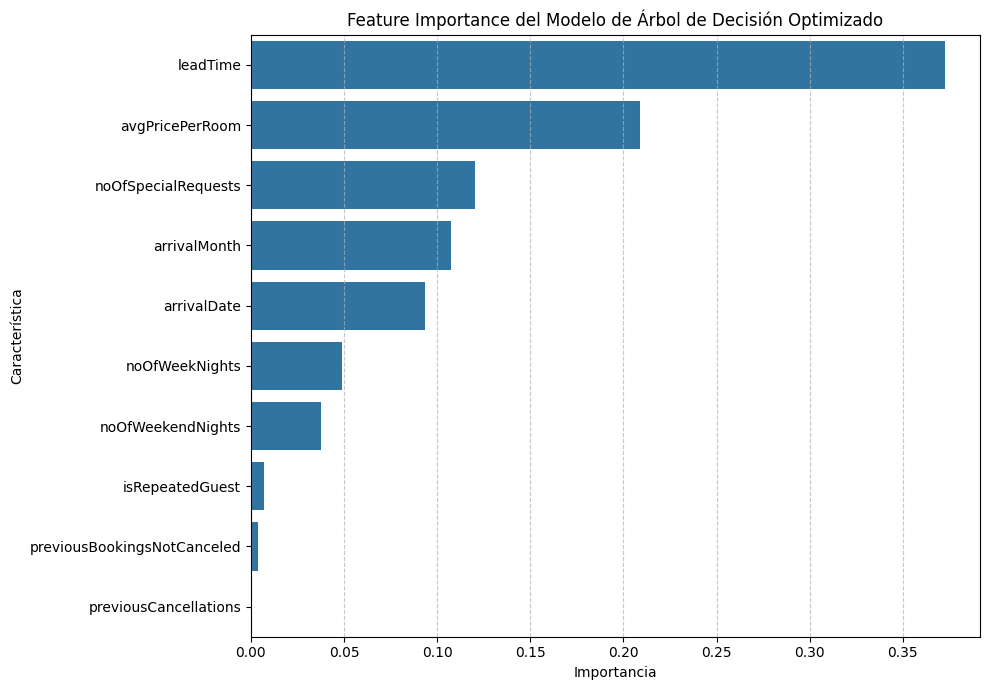

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances from the best optimized model
feature_importances = best_model_opt.feature_importances_

# Get feature names from X_train (since X_test is also imputed and has the same columns)
feature_names = X_train.columns

# Create a DataFrame for better visualization and sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance del Modelo de Árbol de Decisión Optimizado')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 9. Persistencia del modelo

Esta sección aborda un paso crucial en el ciclo de vida de un modelo de Machine Learning: su **persistencia**. Una vez que se ha entrenado y optimizado un modelo, y se ha validado su rendimiento, es necesario guardarlo para poder reutilizarlo sin tener que volver a entrenarlo cada vez. Esto es fundamental para su despliegue en entornos de producción.

Los pasos clave son:

1.  **Guardado del Modelo Entrenado (`best_model.pkl`)**: El modelo optimizado (`best_model_opt`), que en nuestro caso es el `RandomForestClassifier` resultante de `RandomizedSearchCV`, se guarda en un archivo binario utilizando la librería `joblib`. El formato `.pkl` (pickle) es estándar en Python para serializar objetos.
    *   `joblib.dump(best_model_opt, 'best_model.pkl')`: Esta línea guarda el objeto `best_model_opt` en el archivo `best_model.pkl`.

2.  **Guardado del Umbral Óptimo (`best_threshold.pkl`)**: Además del modelo, es vital guardar el umbral de decisión (`best_th`) que se determinó como óptimo para maximizar el `recall` bajo una `precision` mínima. Este umbral es intrínseco a la lógica de negocio y debe usarse junto con el modelo para la toma de decisiones.
    *   `joblib.dump(best_th, 'best_threshold.pkl')`: Esta línea guarda el valor numérico del umbral en el archivo `best_threshold.pkl`.

**Uso en Producción:**

En un entorno de producción (por ejemplo, un servidor web, una aplicación móvil, o un sistema de procesamiento de datos en tiempo real), estos archivos se cargarían para realizar nuevas predicciones:

*   **Carga del Modelo y Umbral**: Se cargarían `best_model.pkl` y `best_threshold.pkl` al iniciar la aplicación o servicio.
    ```python
    import joblib
    loaded_model = joblib.load('best_model.pkl')
    loaded_threshold = joblib.load('best_threshold.pkl')
    ```
*   **Predicción con Nuevos Datos**: Cuando llega una nueva reserva, se procesan sus características, se alimentan al `loaded_model` para obtener las probabilidades de cancelación, y luego se aplica el `loaded_threshold` para determinar si se predice una cancelación o no. De esta manera, el sistema puede operar de forma eficiente y consistente, aplicando la misma lógica entrenada y optimizada.

In [ ]:
import joblib

# Guarda el mejor modelo
joblib.dump(best_model_opt, 'best_model.pkl')
print(f"✔ Modelo '{best_model_name}' guardado como 'best_model.pkl'")

# Guarda el mejor umbral
joblib.dump(best_th, 'best_threshold.pkl')
print(f"✔ Umbral guardado como 'best_threshold.pkl'")


✔ Modelo 'RandomForest' guardado como 'best_model.pkl'
✔ Umbral guardado como 'best_threshold.pkl'


## 10. Visualizacion de evaluacion

La sección 10 se dedica a la visualización de las métricas de evaluación del modelo, lo cual es fundamental para una comprensión profunda de su rendimiento. Se generan las siguientes visualizaciones:

1.  **Curva ROC (Receiver Operating Characteristic)**:
    *   Muestra la capacidad del modelo para distinguir entre las clases positiva y negativa en diferentes umbrales de clasificación.
    *   Un área bajo la curva (AUC) cercana a 1 indica un excelente poder discriminatorio del modelo.

2.  **Curva Precision-Recall**:
    *   Es especialmente útil en problemas con clases desbalanceadas (como la predicción de cancelaciones).
    *   Ilustra el trade-off entre la precisión (proporción de verdaderos positivos entre todas las predicciones positivas) y el recall (proporción de verdaderos positivos entre todas las instancias positivas reales) a medida que el umbral de decisión varía.
    *   Ayuda a visualizar cómo el cambio de umbral afecta la identificación de las cancelaciones verdaderas frente a los falsos positivos.

3.  **Recall vs. Threshold**:
    *   Muestra directamente cómo el valor del recall cambia en función de los diferentes umbrales de probabilidad.
    *   Esta gráfica es crucial para seleccionar el umbral óptimo que maximiza el recall sin sacrificar demasiada precisión, como se hizo en la Sección 7.

4.  **Matriz de Confusión (normalizada y absoluta)**:
    *   Proporciona una vista detallada de los resultados de clasificación, mostrando cuántas predicciones fueron verdaderos positivos (TP), verdaderos negativos (TN), falsos positivos (FP) y falsos negativos (FN).
    *   La matriz normalizada es útil para comparar el rendimiento entre clases y entender las tasas de error relativas.
    *   Permite identificar rápidamente dónde el modelo está cometiendo errores y si tiende a clasificar erróneamente más una clase que otra.

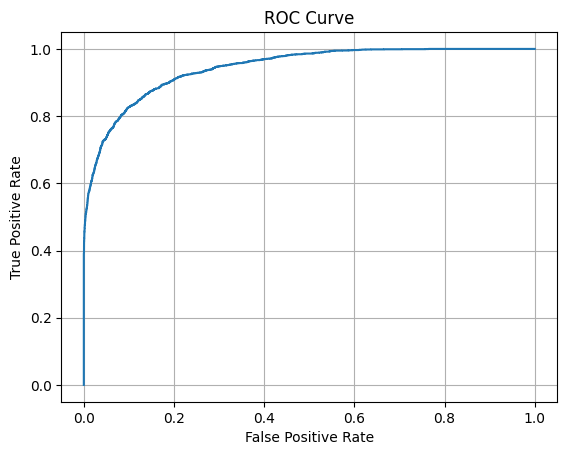

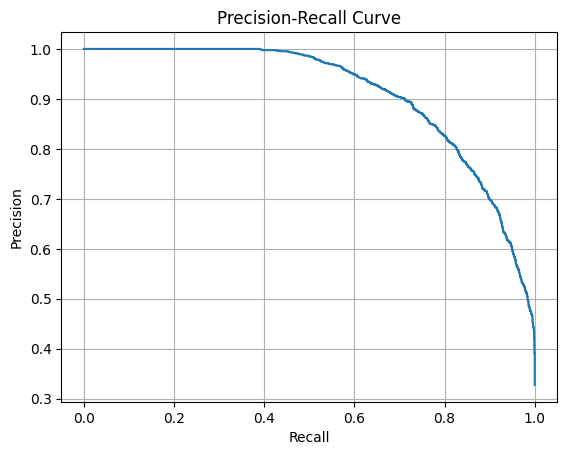

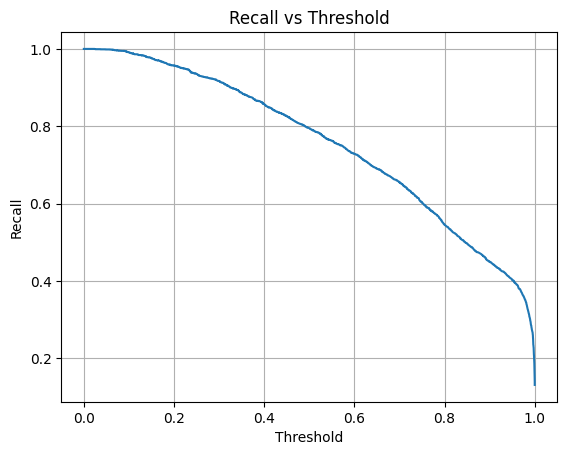

In [ ]:
# @title
# ======================
# 1. ROC Curve
# ======================
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid()
plt.show()

# ======================
# 2. Precision-Recall Curve
# ======================
precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

# ======================
# 3. Recall vs Threshold (basado en thresholds reales)
# ======================
recalls_vs_th = []
for th in pr_thresholds:
    y_pred = (y_proba >= th).astype(int)
    recalls_vs_th.append(recall_score(y_test, y_pred))

plt.plot(pr_thresholds, recalls_vs_th)
plt.title("Recall vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.grid()
plt.show()



--- Métricas Finales ---
Recall: 0.866
Precision: 0.7501
F1 Score: 0.8039

--- Classification Report ---
              precision    recall  f1-score   support

No Cancelado       0.93      0.86      0.89      6098
   Cancelado       0.75      0.87      0.80      2971

    accuracy                           0.86      9069
   macro avg       0.84      0.86      0.85      9069
weighted avg       0.87      0.86      0.86      9069


--- Matriz de Confusión (valores absolutos) ---
[[5241  857]
 [ 398 2573]]

TP: 2573  |  FP: 857  |  FN: 398  |  TN: 5241


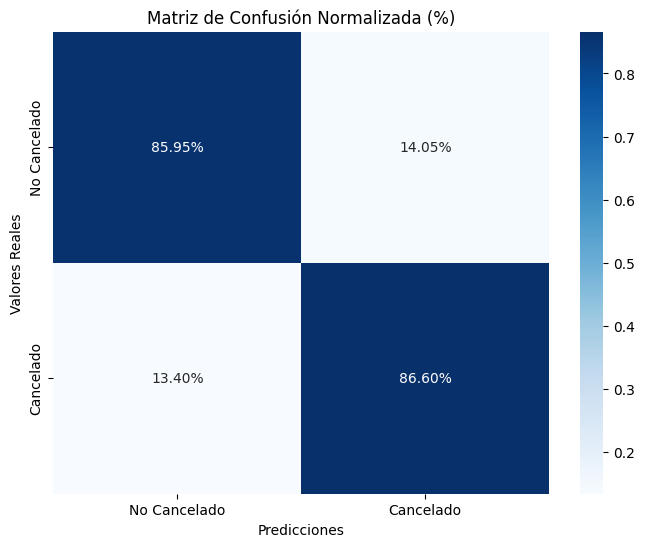

In [ ]:
# @title
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score

# Predicción con el mejor threshold
y_pred_opt = (y_proba >= best_th).astype(int)

print("\n--- Métricas Finales ---")
print("Recall:", round(recall_score(y_test, y_pred_opt), 4))
print("Precision:", round(precision_score(y_test, y_pred_opt), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_opt), 4))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_opt, target_names=["No Cancelado", "Cancelado"]))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp = cm.ravel()

print("\n--- Matriz de Confusión (valores absolutos) ---")
print(cm)
print(f"\nTP: {tp}  |  FP: {fp}  |  FN: {fn}  |  TN: {tn}")

# Matriz normalizada
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['No Cancelado', 'Cancelado'],
            yticklabels=['No Cancelado', 'Cancelado'])
plt.title('Matriz de Confusión Normalizada (%)')
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()


## 11. Funcion de prediccion

Esta sección demuestra cómo utilizar la función `predict_cancellation` para realizar predicciones sobre nuevas reservas y verificar que el modelo y el umbral ajustado (`best_th`) funcionan correctamente. La función toma un DataFrame con los datos de una nueva reserva y devuelve:

*   La `probability_cancel` (probabilidad de cancelación).
*   La `prediction` binaria (1 si se predice cancelación, 0 si no).
*   El nivel de `risk` (riesgo: Bajo, Medio, Alto) basado en la probabilidad.
*   El `threshold_used` (umbral utilizado para la predicción binaria).

Los ejemplos a continuación simulan diferentes escenarios de reservas para ilustrar el comportamiento del modelo:

1.  **Caso de Bajo Riesgo (`low_risk_example`)**: Se construye una reserva con características que históricamente están asociadas a una baja probabilidad de cancelación (ej. `leadTime` corto, `noOfSpecialRequests` alto, `isRepeatedGuest`, `previousBookingsNotCanceled` alto).
2.  **Caso de Riesgo Medio (`medium_risk_example`)**: Se crea una reserva con una combinación de factores que sitúan su probabilidad de cancelación en un rango intermedio, a menudo cerca del umbral de decisión.
3.  **Caso de Alto Riesgo (`high_risk_auto`)**: Se definen características que el modelo ha identificado como fuertes indicadores de cancelación (ej. `leadTime` largo, `previousCancellations` alto, `avgPricePerRoom` alto, `noOfSpecialRequests` bajo, `isRepeatedGuest` bajo).

Al ejecutar estos ejemplos, se puede observar cómo la función `predict_cancellation` asigna diferentes probabilidades y niveles de riesgo, lo que permite validar su lógica y la capacidad del modelo para diferenciar entre distintos perfiles de reserva.

In [ ]:
EXPECTED_COLUMNS = X_train.columns.tolist()

def predict_cancellation(input_df, model=best_model_opt, threshold=best_th):
    try:
        # asegurar que las columnas estén en el mismo orden
        input_df = input_df[EXPECTED_COLUMNS]

        # obtener probabilidad
        proba = float(model.predict_proba(input_df)[0][1])

        # predicción con threshold ajustado
        prediction = int(proba >= threshold)

        # clasificación de riesgo
        if proba >= 0.7:
            risk = "HIGH"
        elif proba >= 0.4:
            risk = "MEDIUM"
        else:
            risk = "LOW"

        return {
            "probability_cancel": proba,
            "prediction": prediction,
            "risk": risk,
            "threshold_used": float(threshold)
        }

    except Exception as e:
        return {"error": str(e)}


In [ ]:
# ==========================
# 🟢 Caso de BAJO RIESGO
# ==========================

import pandas as pd

TEST_COLUMNS = [
    "leadTime",
    "avgPricePerRoom",
    "noOfSpecialRequests",
    "arrivalDate",
    "arrivalMonth",
    "noOfWeekNights",
    "noOfWeekendNights",
    "previousCancellations",
    "previousBookingsNotCanceled",
    "isRepeatedGuest"
]

low_risk_example = pd.DataFrame([{
    "leadTime": 10,           # Reserva cercana → poco riesgo
    "avgPricePerRoom": 90,
    "noOfSpecialRequests": 1,
    "arrivalDate": 20,
    "arrivalMonth": 3,
    "noOfWeekNights": 2,
    "noOfWeekendNights": 1,
    "previousCancellations": 0,
    "previousBookingsNotCanceled": 5,  # Historial muy bueno
    "isRepeatedGuest": 1                # Cliente repetido → menos riesgo
}], columns=TEST_COLUMNS)

print("🟢 Predicción BAJO RIESGO")
print(predict_cancellation(low_risk_example))


🟢 Predicción BAJO RIESGO
{'probability_cancel': 0.045525890199321385, 'prediction': 0, 'risk': 'LOW', 'threshold_used': 0.38343035782530777}


In [ ]:
# ==========================
# 🟡 Caso de RIESGO MEDIO
# ==========================

medium_risk_example = pd.DataFrame([{
    "leadTime": 60,          # 2 meses antes
    "avgPricePerRoom": 130,
    "noOfSpecialRequests": 0,
    "arrivalDate": 8,
    "arrivalMonth": 7,
    "noOfWeekNights": 3,
    "noOfWeekendNights": 1,
    "previousCancellations": 1,
    "previousBookingsNotCanceled": 1,
    "isRepeatedGuest": 0
}], columns=TEST_COLUMNS)

print("🟡 Predicción RIESGO MEDIO")
print(predict_cancellation(medium_risk_example))


🟡 Predicción RIESGO MEDIO
{'probability_cancel': 0.585092526086824, 'prediction': 1, 'risk': 'MEDIUM', 'threshold_used': 0.38343035782530777}


In [ ]:
# ==========================
# 🔴 Caso de ALTO RIESGO
# ==========================

high_risk_auto = pd.DataFrame([{
    "leadTime": 95,                     # Lead time medio-largo (muy común en cancelaciones)
    "avgPricePerRoom": 260,             # Precio alto → más volátil
    "noOfSpecialRequests": 0,           # Clientes con pocas solicitudes suelen cancelar más
    "arrivalDate": 3,                   # Fechas tempranas del mes correlacionan con mayor riesgo
    "arrivalMonth": 11,                 # Meses altos en cancelación (ej: noviembre)
    "noOfWeekNights": 1,
    "noOfWeekendNights": 0,
    "previousCancellations": 7,         # Historial fuertemente negativo
    "previousBookingsNotCanceled": 0,   # Casi ninguna reserva completada
    "isRepeatedGuest": 0                # No es cliente frecuente → mayor volatilidad
}], columns=TEST_COLUMNS)

print("🔴 Predicción ALTO RIESGO")
print(predict_cancellation(high_risk_auto))


🔴 Predicción ALTO RIESGO
{'probability_cancel': 0.7275998767359526, 'prediction': 1, 'risk': 'HIGH', 'threshold_used': 0.38343035782530777}
